=== WYNIKI REGRESJI ===
Współczynnik a: 7.9560
Współczynnik b: 15.9120
Otrzymane równanie: y = 7.9560 * x1 + 15.9120 * x2



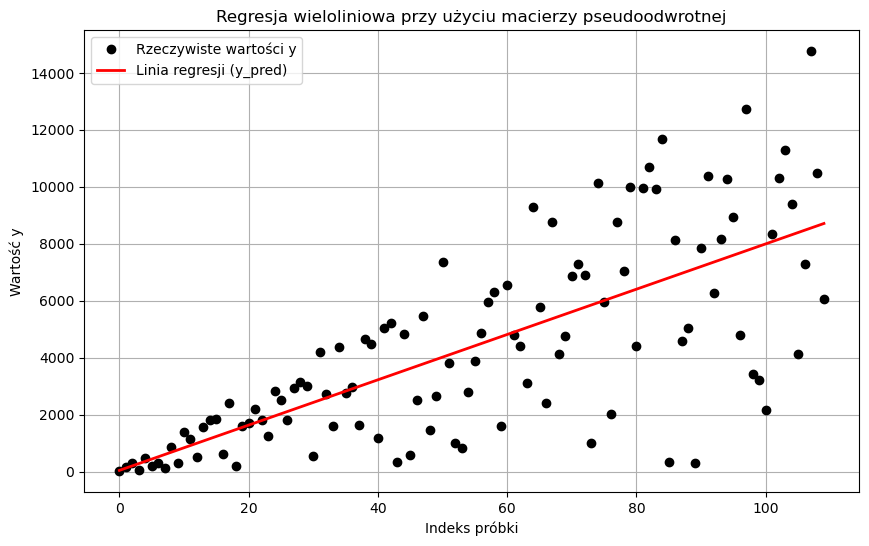

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_name = 'war11.csv' 
try:
    df = pd.read_csv(file_name, sep=';', decimal=',')
except FileNotFoundError:
    print(f"Błąd: Nie znaleziono pliku '{file_name}'. Upewnij się, że jest w tym samym folderze co notatnik.")

x1 = df['x1'].values
x2 = df['x2'].values
y = df['y'].values

A = np.column_stack((x1, x2))

b = y.reshape(-1, 1)

#Obliczenie regresji za pomocą macierzy pseudoodwrotnej (wzór y = ax1 + bx2)
# Używamy np.linalg.pinv
A_pinv = np.linalg.pinv(A)

# Mnożymy macierz pseudoodwrotną przez wektor b, aby uzyskać niewiadome a i b
x_solution = A_pinv @ b

# Wyciągnięcie wyników
a = x_solution[0][0]
b_wsp = x_solution[1][0]

print("=== WYNIKI REGRESJI ===")
print(f"Współczynnik a: {a:.4f}")
print(f"Współczynnik b: {b_wsp:.4f}")
print(f"Otrzymane równanie: y = {a:.4f} * x1 + {b_wsp:.4f} * x2\n")

#Wizualizacja
y_pred = A @ x_solution

plt.figure(figsize=(10, 6))

plt.plot(y, 'ko', label='Rzeczywiste wartości y', markersize=6)
plt.plot(y_pred, 'r-', label='Linia regresji (y_pred)', linewidth=2)

plt.title('Regresja wieloliniowa przy użyciu macierzy pseudoodwrotnej')
plt.xlabel('Indeks próbki')
plt.ylabel('Wartość y')
plt.legend()
plt.grid(True)
plt.show()

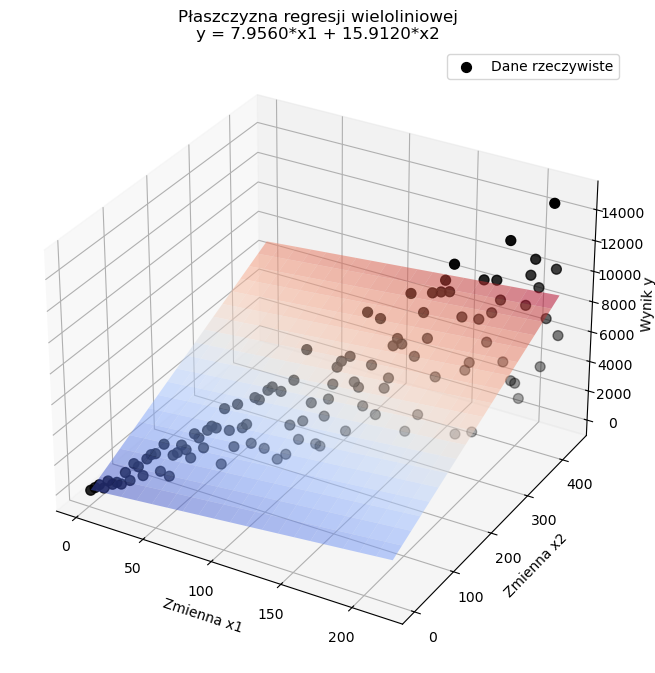

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, color='black', label='Dane rzeczywiste', s=50)

x1_range = np.linspace(x1.min(), x1.max(), 20)
x2_range = np.linspace(x2.min(), x2.max(), 20)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z = a * X1 + b_wsp * X2 

surf = ax.plot_surface(X1, X2, Z, alpha=0.5, cmap='coolwarm', edgecolor='none')

ax.set_xlabel('Zmienna x1')
ax.set_ylabel('Zmienna x2')
ax.set_zlabel('Wynik y')
ax.set_title(f'Płaszczyzna regresji wieloliniowej\ny = {a:.4f}*x1 + {b_wsp:.4f}*x2')

plt.legend()
plt.show()